In [1]:
import torch
import torch.nn as nn
import numpy as np
import os
from torch.utils.data import DataLoader

# ==================== 1. 从你整理好的 model 和 dataset 库中导入核心组件 ====================
from dataset import CityscapesDataset
from model import DPAI_DeepLabV3P_Segmentation, CombinedLoss

# ==================== 2. 训练器定义 ====================
class SegmentationTrainer:
    # 注意把存放权重的目录改叫 checkpoints_deeplab 防止和其它的覆盖
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, scheduler, device, save_dir='checkpoints_deeplab'):
        self.model, self.train_loader, self.val_loader = model, train_loader, val_loader
        self.criterion, self.optimizer, self.scheduler, self.device = criterion, optimizer, scheduler, device
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)
        self.epoch_loss_history = []
        self.best_miou, self.epoch = 0, 0

    def train_epoch(self):
        self.model.train()
        total_loss, running_loss = 0, 0.0
        log_interval = 50

        for batch_idx, (images, targets, _, _) in enumerate(self.train_loader):
            images, targets = images.to(self.device), targets.to(self.device)
            outputs = self.model(images)
            loss = self.criterion(outputs, targets)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            loss_val = loss.item()
            total_loss += loss_val
            running_loss += loss_val

            if (batch_idx + 1) % log_interval == 0:
                avg_batch_loss = running_loss / log_interval
                print(f"  Epoch {self.epoch+1}, Batch {batch_idx+1}, Group Avg Loss: {avg_batch_loss:.4f}")
                running_loss = 0.0

        return total_loss / len(self.train_loader)

    @torch.no_grad()
    def validate(self):
        self.model.eval()
        total_loss, confusion_matrix = 0, np.zeros((19, 19))
        for images, targets, _, _ in self.val_loader:
            images, targets = images.to(self.device), targets.to(self.device)
            outputs = self.model(images)
            total_loss += self.criterion(outputs, targets).item()
            preds = outputs.argmax(dim=1).cpu().numpy()

            for t, p in zip(targets.cpu().numpy(), preds):
                mask = (t != 255)
                label = 19 * t[mask].astype('int') + p[mask]
                confusion_matrix += np.bincount(label, minlength=19**2).reshape(19, 19)

        iu = np.diag(confusion_matrix) / (confusion_matrix.sum(axis=1) + confusion_matrix.sum(axis=0) - np.diag(confusion_matrix) + 1e-10)
        return total_loss / len(self.val_loader), np.mean(iu)

    def train(self, num_epochs):
        for epoch in range(num_epochs):
            self.epoch = epoch
            print(f"\nEpoch {epoch+1}/{num_epochs}")

            avg_epoch_loss = self.train_epoch()
            val_loss, val_miou = self.validate()

            self.epoch_loss_history.append({'epoch': epoch + 1, 'train_loss': avg_epoch_loss, 'val_loss': val_loss, 'miou': val_miou})

            print(f"--- Epoch {epoch+1} Summary ---")
            print(f"Average Train Loss: {avg_epoch_loss:.6f}")
            print(f"Average Val Loss:   {val_loss:.6f}")
            print(f"mIoU:               {val_miou:.4f}")

            if val_miou > self.best_miou:
                self.best_miou = val_miou
                # 兼容多卡的保存安全逻辑
                model_to_save = self.model.module if hasattr(self.model, 'module') else self.model
                torch.save(model_to_save.state_dict(), os.path.join(self.save_dir, 'DPAI_DeepLabV3P.pth'))
                print("🏆 创新高！保存最佳模型!")

# ==================== 3. 驱动脚本 ====================
def main():
    root_dir = r"E:\Laboratory files\code_project\city_data"  # 请核对你的路径
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 1. 实例化咱们组装好的 DeepLabV3+ 改进模型
    model = DPAI_DeepLabV3P_Segmentation(num_classes=19, pretrained=True)

    # 2. 自动检测和开启双路 4090 显卡加速
    if torch.cuda.device_count() > 1:
        print(f"🔥 检测到 {torch.cuda.device_count()} 张显卡，开启 nn.DataParallel 多卡加速！")
        model = nn.DataParallel(model)
    model = model.to(device)

    # 3. 准备数据
    train_dataset = CityscapesDataset(root_dir, 'train')
    val_dataset = CityscapesDataset(root_dir, 'val')

    print(f"训练集图片: {len(train_dataset)} | 验证集图片: {len(val_dataset)}")

    # 4090显卡显存大，你可以尝试把这里的 batch_size 改成 16 享受更快的速度
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8)

    # 4. 指定为我们在 model.py 里准备好的牛逼的 CombinedLoss (包含了 Dice 和 Focal)
    criterion = CombinedLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # 5. 起飞！
    trainer = SegmentationTrainer(model, train_loader, val_loader, criterion, optimizer, None, device, save_dir='checkpoints_deeplab')
    trainer.train(num_epochs=50)

# if __name__ == "__main__":
#     main()


✅ ASPP + DPAI 究极权重部署完毕，准备起飞！


C:\Users\GaoZixian\AppData\Local\Temp\ipykernel_12048\1692782566.py:94: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\GaoZixian\AppData\Local\Temp\ipykernel_12048\1692782566.py:94: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\GaoZixian\AppData\Local\Temp\ipykernel_12048\1692782566.py:94: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


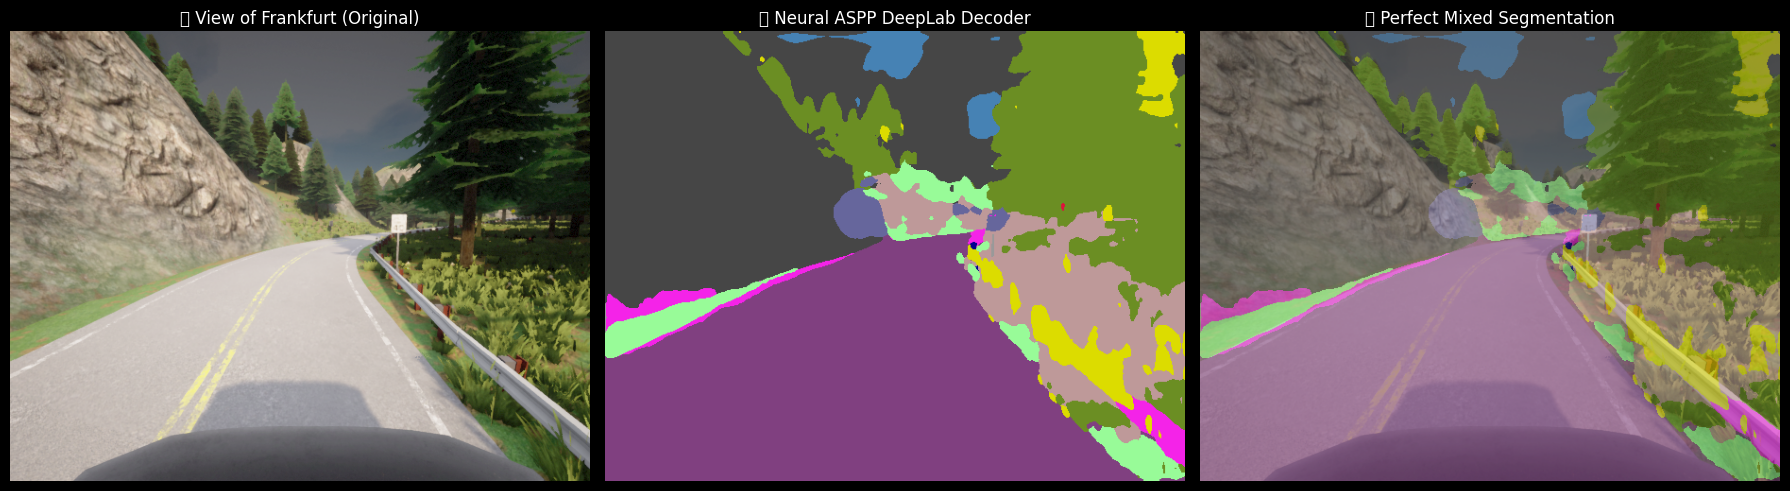

📁 绘画归档进程结束，图片留影在：[visual_results_deeplab] 文件夹里等待检阅


In [3]:
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

# ==================== 1. 从 model.py 中引入你的巅峰解码器模型 ====================
from model import DPAI_DeepLabV3P_Segmentation

def load_deeplab_model_weight(model, weight_path, device):
    """装载你辛辛苦苦跑出来的 DeepLabV3+ 的 .pth 权重文件"""
    if not os.path.exists(weight_path):
        print(f"❌ 哎呀，找不到权重文件，麻烦检查一下这个路径在不在: {weight_path}")
        return model

    # 1. 从磁盘榨取权重字典
    state_dict = torch.load(weight_path, map_location=device)

    # 2. 强效过滤由于多卡 nn.DataParallel 在保存时可能偷偷加上的 'module.' 污点前缀
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k
        new_state_dict[name] = v

    # 启用严格的神经元对齐载入 (Strict=True)
    model.load_state_dict(new_state_dict, strict=True)
    model.to(device)
    # 将模型正式切换为只读评估形态，彻底镇压 BN 层的均值漂移和 Dropout 的捣乱
    model.eval()
    print("✅ ASPP + DPAI 究极权重部署完毕，准备起飞！")
    return model

def predict_and_visualize(model, image_path, device, target_size=(1024, 512), save_dir='visual_results_deeplab'):
    """接受任意街景图像，提取 DeepLabV3+ ASPP 感受野并作画"""

    # 一脉相承的 Cityscapes 19 阶法定色彩卡字典
    class_colors = {
        0: [128, 64, 128], 1: [244, 35, 232], 2: [70, 70, 70], 3: [102, 102, 156],
        4: [190, 153, 153], 5: [153, 153, 153], 6: [250, 170, 30], 7: [220, 220, 0],
        8: [107, 142, 35], 9: [152, 251, 152], 10: [70, 130, 180], 11: [220, 20, 60],
        12: [255, 0, 0], 13: [0, 0, 142], 14: [0, 0, 70], 15: [0, 60, 100],
        16: [0, 80, 100], 17: [0, 0, 230], 18: [119, 11, 32], 255: [0, 0, 0]
    }

    # 创建专门存放 DeepLab 渲染图片的收纳盒
    os.makedirs(save_dir, exist_ok=True)

    # --- 1. 读取相机的光学原图并压缩尺度 (100% 对齐数据管道 DataLoader 的手作逻辑) ---
    original_img = Image.open(image_path).convert('RGB')
    orig_w, orig_h = original_img.size

    resized_img = original_img.resize(target_size, Image.BILINEAR)
    img_tensor = torch.from_numpy(np.array(resized_img)).permute(2, 0, 1).float() / 255.0
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # --- 2. 切断梯度回流，纯享推演过程 ---
    with torch.no_grad():
        output = model(input_tensor)
        # 用插值把 ASPP 粗犷出来的 Mask 重新填充到原图真正的 2K 摄影尺寸上
        output = F.interpolate(output, size=(orig_h, orig_w), mode='bilinear', align_corners=False)

    # 取置信度最高的网络判断频道对应的下标
    pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    # --- 3. 按照标准表赋予每个像素专属的漆色 ---
    color_mask = np.zeros((orig_h, orig_w, 3), dtype=np.uint8)
    for label, color in class_colors.items():
        color_mask[pred_mask == label] = color
    color_mask_img = Image.fromarray(color_mask)

    # --- 4. 半透镜叠加融合术 (Alpha 浓度设为 0.55，既不过分突兀也不干扰底层路形) ---
    blended = Image.blend(original_img, color_mask_img, alpha=0.55)

    # --- 5. 小舞台画展 (Matplotlib 主持) ---
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.title("📸 View of Frankfurt (Original)")
    plt.imshow(original_img)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("🧠 Neural ASPP DeepLab Decoder")
    plt.imshow(color_mask_img)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("🎯 Perfect Mixed Segmentation")
    plt.imshow(blended)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # --- 6. 将你的模型成果归档封存，供论文拿去发表 ---
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    blended.save(os.path.join(save_dir, f"DeepLabV3P_blended_{timestamp}.png"))
    color_mask_img.save(os.path.join(save_dir, f"DeepLabV3P_mask_{timestamp}.png"))
    print(f"📁 绘画归档进程结束，图片留影在：[{save_dir}] 文件夹里等待检阅")

# ======================= 👇 点燃引擎区 👇 =======================

# 推断不需要借用大炮打蚊子并发两张显卡，留 cuda:0 一张卡干活就好
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 召唤咱们最新的猛兽 DeepLabV3+
deeplab_eval_model = DPAI_DeepLabV3P_Segmentation(num_classes=19, pretrained=False)

# 告诉它刚才那个通宵跑出来的最高权重的隐藏宝库在哪 (注意确认这个文件名对不对)
ckpt_path = 'dpai_deeplabv3p/DPAI_DeepLabV3P.pth'
deeplab_eval_model = load_deeplab_model_weight(deeplab_eval_model, ckpt_path, device)

# 从你硬盘里找一张街景图来看看效果
# test_img_path = r'E:\Laboratory files\code_project\city_data\leftImg8bit\val\frankfurt\frankfurt_000000_000294_leftImg8bit.png'
test_img_path = r'E:\Laboratory files\code_project\city_data\figure2.png'
# Let's Go
predict_and_visualize(deeplab_eval_model, test_img_path, device)
